In [537]:
#x = 11
#https://www.kaggle.com/datasets/kritikseth/fruit-and-vegetable-image-recognition

wyekstrahować zestaw cech (kształt, ?
dla kilku owoców (jabłko, banan, ananas) (2-3)
1 zdjecie, wyznaczymy dla jabłka, wtedy wziąć reszte zdjęć i dla każdego z tych zdjęc wyekstrahować cechy

to samo dla ananasów, bananów etc

ta sama cecha, np długość

potem potworzyć wykresy dla każdego owocu



In [538]:
#import kagglehub

# Download latest version
#path = kagglehub.dataset_download("kritikseth/fruit-and-vegetable-image-recognition")

#print("Path to dataset files:", path)

In [539]:
path = "../fruit-and-vegetable-image-recognition"

In [540]:
#!pip install pandas seaborn matplotlib

In [541]:
#!python -m pip install opencv-python

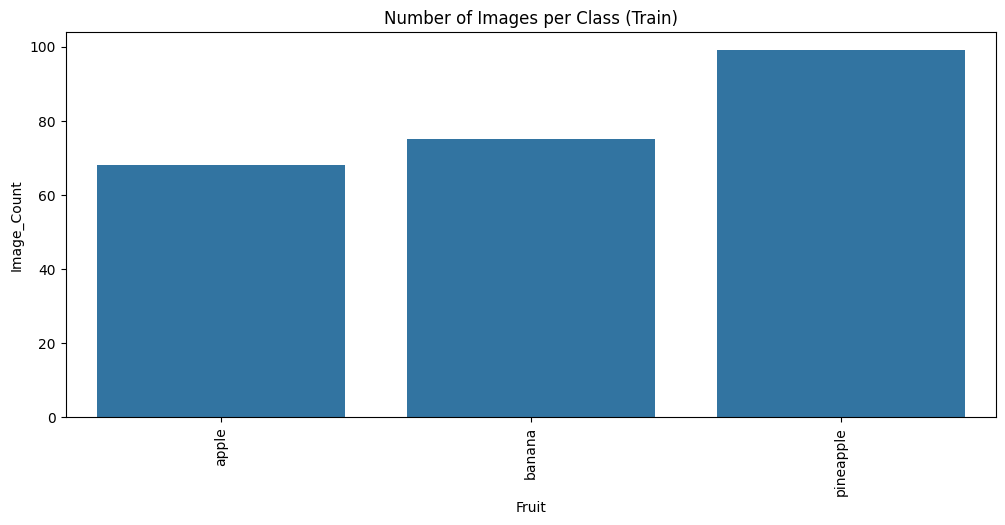

In [542]:
import pandas as pd
import seaborn
import matplotlib.pyplot as plt
import os

fruits = ["apple", "banana", "pineapple"]
image_count = {}

for fruit in fruits:
    fruit_path = os.path.join(path + '/train', fruit)
    image_count[fruit] = len(os.listdir(fruit_path))

df = pd.DataFrame(image_count.items(), columns=["Fruit", "Image_Count"])

plt.figure(figsize=(12,5))
seaborn.barplot(x="Fruit", y="Image_Count", data=df)
plt.xticks(rotation=90)
plt.title("Number of Images per Class (Train)")
plt.show()

In [543]:
import cv2
import matplotlib.pyplot as plt

def segment_image(image_path):
    image = cv2.imread(image_path)
    if image is None:
        print("Failed to load image:", image_path)
        return

    # Skalowanie - ujednolicenie rozdzielczosci
    image = cv2.resize(image, (256, 256))
    plt.imshow(image)

    # Odszumianie - filtr medianowy - zastępuje każdy piksel medianą wartości pikseli z jego najbliższego otoczenia (5x5).
    image = cv2.medianBlur(image, 5)
    plt.imshow(image)

    # konwersja na HSV
    hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    plt.imshow(hsv_image)


In [544]:
import cv2

def BGR2RGB(image):
  return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

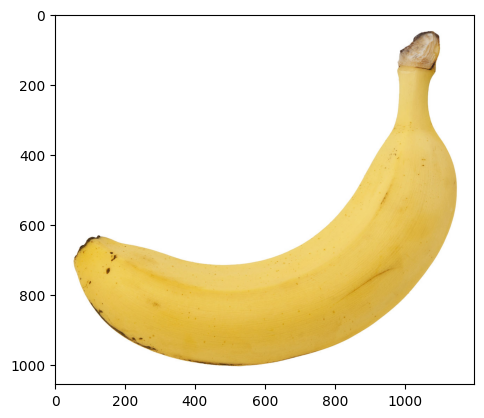

In [545]:
import matplotlib.pyplot as plt
img = cv2.imread(path + '/train/banana/Image_3.jpg')
if img is None:
    print("Failed to load image:", img)

# matplotlib potrzebuje RGB, cv2 podaje BGR
plt.imshow(BGR2RGB(img))

In [546]:
# Skalowanie - ujednolicenie rozdzielczosci
# img = cv2.resize(img, (256, 256))
# plt.imshow(BGR2RGB(img))

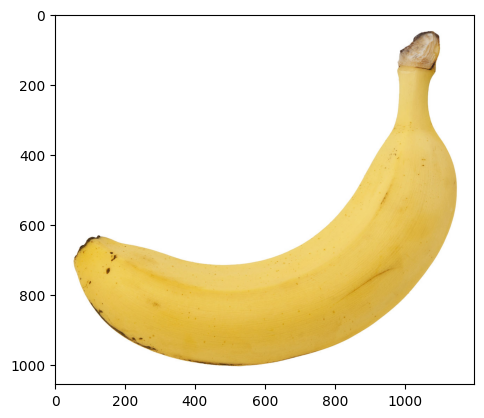

In [547]:
# Odszumianie - filtr medianowy - zastępuje każdy piksel medianą wartości pikseli z jego najbliższego otoczenia (5x5).
blurred_img = cv2.medianBlur(img, 5)
plt.imshow(BGR2RGB(img))

hsv jest lepsze dla klasyfikacji, bardziej odporne na zmiany oświetlenia

In [548]:
# konwersja na HSV
hsv_img = cv2.cvtColor(blurred_img, cv2.COLOR_BGR2HSV)


In [549]:
hist = cv2.calcHist([img], [0, 1], None, [50, 50], [0, 180, 0, 256])
cv2.normalize(hist, hist)
hist.flatten()


array([0.00018978, 0.00011861, 0.00023722, ..., 0.        , 0.        ,
       0.        ], shape=(2500,), dtype=float32)

In [550]:
import numpy as np
# Progowanie nasycenia (S) i jasności (V)
# Przyjmujemy, że owoc jest nasycony i dość jasny.
# Wartości te mogą wymagać kalibracji!
lower_bound = np.array([0, 50, 50])  # Niska saturacja dla tła
upper_bound = np.array([179, 255, 255]) # Wysoka saturacja i jasność

mask = cv2.inRange(hsv_img, lower_bound, upper_bound)

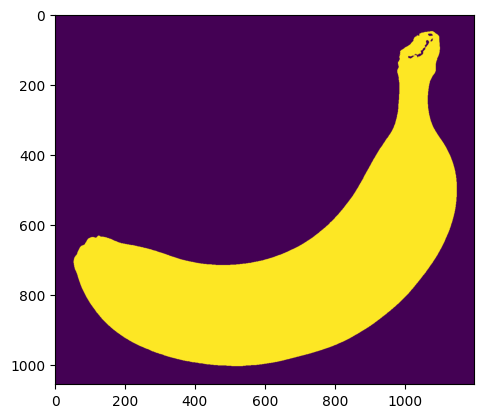

In [551]:
plt.imshow(mask)

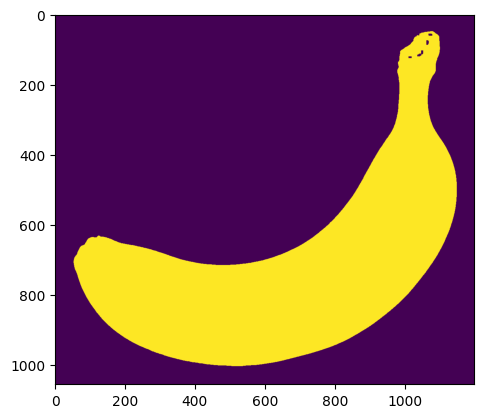

In [552]:
# Operacje morfologiczne - Zamknięcie (Dylacja, potem Erozja) - usunięcie dziur + wygładzenie maski
kernel = np.ones((5,5), np.uint8)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
plt.imshow(mask)

In [553]:
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

In [554]:
largest_contour = max(contours, key=cv2.contourArea)

In [555]:
# Stworzenie maski tylko dla największego konturu
object_mask = np.zeros_like(mask)
# -1 - indeks konturu - wszystkie z listy rysujemy
# 255 - kolor
# -1 grubośc lini - kontur wypełniony
cv2.drawContours(object_mask, [largest_contour], -1, 255, -1)

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(1057, 1200), dtype=uint8)

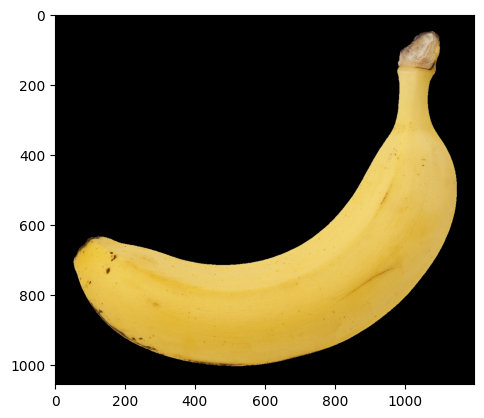

In [556]:
fruit_only = cv2.bitwise_and(img, img, mask=object_mask)
plt.imshow(BGR2RGB(fruit_only))

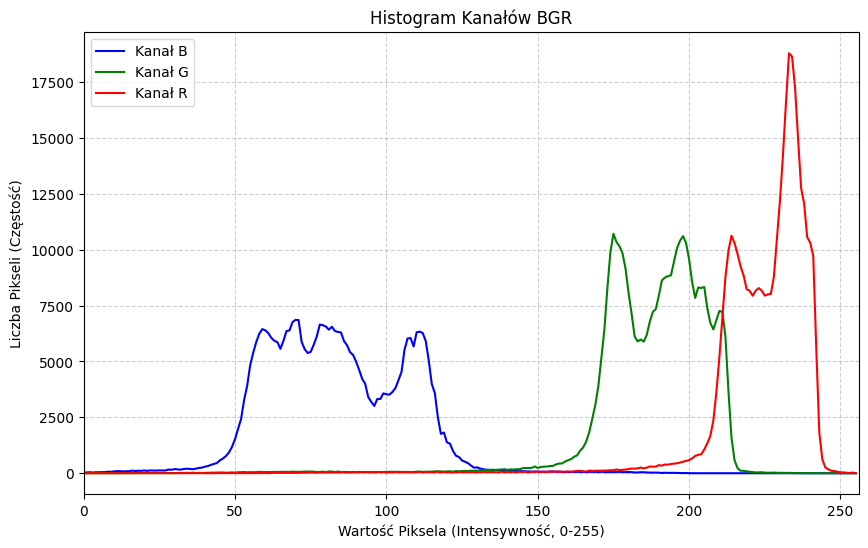

In [557]:
import numpy as np
# Ustalenie koloru dla każdego kanału na wykresie
color = ('b', 'g', 'r')

plt.figure(figsize=(10, 6))
plt.title('Histogram Kanałów BGR')
plt.xlabel('Wartość Piksela (Intensywność, 0-255)')
plt.ylabel('Liczba Pikseli (Częstość)')

# 2. Obliczanie i Wyświetlanie Histogramu dla Każdego Kanału

# Przechodzimy przez każdy kanał (indeksy 0=B, 1=G, 2=R)
for i, col in enumerate(color):

    # Obliczenie histogramu dla pojedynczego kanału
    # [img]: obraz wejściowy
    # [i]: indeks kanału (0, 1 lub 2)
    # None: brak maski
    # [256]: liczba kubełków (cały zakres 0-255)
    # [1, 256]: zakres wartości - bez 0, zeby wyciac czarny
    hist = cv2.calcHist([fruit_only], [i], None, [256], [1, 256])

    # Wyświetlenie histogramu
    # Podzielenie przez sumę, aby uzyskać znormalizowany (prawdopodobieństwo) wykres, choć nie jest to ścisła normalizacja sumy do 1
    plt.plot(hist, color=col, label=f'Kanał {col.upper()}')

    # Normalizacja Matplotlib dla lepszej czytelności skali, jeśli potrzeba
    plt.xlim([0, 256])

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Ekstrakcja cech

In [558]:
import pandas as pd
column_labels = [
    'H_Mean', 'S_Mean', 'V_Mean',
    'H_Std', 'S_Std', 'V_Std',
    'Aspect_Ratio', "Eccentricity", "Solidity", "Convexity"
]
df_features = pd.DataFrame(columns=column_labels)
df_features

,H_Mean,S_Mean,V_Mean,H_Std,S_Std,V_Std,Aspect_Ratio,Eccentricity,Solidity,Convexity


In [559]:
h_channel = hsv_img[:, :, 0][object_mask == 255]
s_channel = hsv_img[:, :, 1][object_mask == 255]
v_channel = hsv_img[:, :, 2][object_mask == 255]

In [560]:
color_features = []

In [561]:
# Średnia (Dominujący kolor/odcień)
color_features.extend([np.mean(h_channel), np.mean(s_channel), np.mean(v_channel)])
# Odchylenie standardowe (Rozrzut koloru/odcienia)
color_features.extend([np.std(h_channel), np.std(s_channel), np.std(v_channel)])


In [562]:
print(color_features)

[np.float64(22.218270588516862), np.float64(159.56444008328745), np.float64(225.8503724268509), np.float64(1.236394576697297), np.float64(22.97654990251432), np.float64(15.856265382854076)]


Aspect ratio

In [563]:
x, y, w, h = cv2.boundingRect(largest_contour)

In [564]:
aspect_ratio = w / h if h != 0 else 0
aspect_ratio

1.1442006269592477

Ekscentryczność - jak bardzo kształt odbiega od koła w kierunku elipsy. Jest to stosunek osi eliptycznego dopasowania do konturu:

In [565]:
from skimage.measure import label, regionprops

labeled_img = label(object_mask)
region = regionprops(labeled_img)[0]
eccentricity = region.eccentricity
print(eccentricity)




# # 1. Dopasowanie elipsy do konturu
# ellipse = cv2.fitEllipse(largest_contour)

# # 2. Oś długa i krótka (osi elipsy)
# (center, axes, orientation) = ellipse
# major_axis = max(axes)
# minor_axis = min(axes)

# # 3. Obliczenie Ekscentryczności
# if major_axis == 0:
#     eccentricity = 0
# else:
#     # Wzór OpenCV/standardowy
#     eccentricity = np.sqrt(1 - (minor_axis / major_axis)**2)

# eccentricity

0.8984783195062951


Solidity = area / convex_area

blisko 1 - obiekt zwiezly, wypukly
duzo mniejsze od 1 - obiekt z dziurami, wcieciami

In [566]:
solidity = region.solidity
solidity

np.float64(0.6046384119291826)

Area, convex area

In [567]:
area = region.area
area

np.float64(376047.0)

In [568]:
convex_area = region.convex_area
convex_area

np.float64(621937.0)

Convexity - jak bardzo jest wypukly

In [569]:
perimeter = cv2.arcLength(largest_contour, True)
convex_hull_perimeter = cv2.arcLength(cv2.convexHull(largest_contour), True)
convexity = convex_hull_perimeter / perimeter
convexity

0.8708872954227475

Wektor cech

In [570]:
feature_vector = np.array(color_features + [aspect_ratio] + [eccentricity] + [solidity] + [convexity])
feature_vector

array([ 22.21827059, 159.56444008, 225.85037243,   1.23639458,
        22.9765499 ,  15.85626538,   1.14420063,   0.89847832,
         0.60463841,   0.8708873 ])

In [571]:
# Utworzenie nowego wiersza jako obiektu Series
new_row = pd.Series(feature_vector, index=column_labels)

# Dodanie wiersza do DataFrame (używamy .to_frame().T, aby Series stało się wierszem)
df_features = pd.concat([df_features, new_row.to_frame().T], ignore_index=True)
df_features

C:\Users\jedre\AppData\Local\Temp\ipykernel_5024\4279743308.py:5: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_features = pd.concat([df_features, new_row.to_frame().T], ignore_index=True)


,H_Mean,S_Mean,V_Mean,H_Std,S_Std,V_Std,Aspect_Ratio,Eccentricity,Solidity,Convexity
0,22.218271,159.56444,225.850372,1.236395,22.97655,15.856265,1.144201,0.898478,0.604638,0.870887


In [572]:
import pandas as pd
column_labels = [
    'Class', 'H_Mean', 'S_Mean', 'V_Mean',
    'H_Std', 'S_Std', 'V_Std',
    'Aspect_Ratio', "Eccentricity", "Solidity", "Convexity"
]
df_train = pd.DataFrame(columns=column_labels)
df_train

,Class,H_Mean,S_Mean,V_Mean,H_Std,S_Std,V_Std,Aspect_Ratio,Eccentricity,Solidity,Convexity


In [573]:
df_test = pd.DataFrame(columns=column_labels)
df_test

,Class,H_Mean,S_Mean,V_Mean,H_Std,S_Std,V_Std,Aspect_Ratio,Eccentricity,Solidity,Convexity


In [574]:
#!pip install scikit-image

In [575]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

def extract_features(df_features, image_path, fruit):
    image = cv2.imread(image_path)
    if image is None:
        print("Failed to load image:", image_path)
        return

    # Skalowanie - ujednolicenie rozdzielczosci - NIE UZYWAĆ
    # image = cv2.resize(image, (256, 256))

    # Odszumianie - filtr medianowy - zastępuje każdy piksel medianą wartości pikseli z jego najbliższego otoczenia (5x5).
    image = cv2.medianBlur(image, 5)

    # konwersja na HSV
    hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # Progowanie nasycenia (S) i jasności (V)
    # Przyjmujemy, że owoc jest nasycony i dość jasny.
    lower_bound = np.array([0, 50, 50])  # Niska saturacja dla tła
    upper_bound = np.array([179, 255, 255]) # Wysoka saturacja i jasność
    mask = cv2.inRange(hsv_image, lower_bound, upper_bound)

    # Operacje morfologiczne - Zamknięcie (Dylacja, potem Erozja) - usunięcie dziur + wygładzenie maski
    kernel = np.ones((5,5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    # znalezienie kontur
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    largest_contour = max(contours, key=cv2.contourArea)

    # Stworzenie maski tylko dla największego konturu
    object_mask = np.zeros_like(mask)
    # -1 - indeks konturu - wszystkie z listy rysujemy
    # 255 - kolor
    # -1 grubośc lini - kontur wypełniony
    cv2.drawContours(object_mask, [largest_contour], -1, 255, -1)

    plt.show

    #fruit_only = cv2.bitwise_and(image, image, mask=object_mask)

    # ekstrakcja cech
    h_channel = hsv_image[:, :, 0][object_mask == 255]
    s_channel = hsv_image[:, :, 1][object_mask == 255]
    v_channel = hsv_image[:, :, 2][object_mask == 255]

    color_features = []
    # Średnia (Dominujący kolor/odcień)
    color_features.extend([np.mean(h_channel), np.mean(s_channel), np.mean(v_channel)])
    # Odchylenie standardowe (Rozrzut koloru/odcienia)
    color_features.extend([np.std(h_channel), np.std(s_channel), np.std(v_channel)])

    # aspect ratio
    x, y, w, h = cv2.boundingRect(largest_contour)
    aspect_ratio = w / h if h != 0 else 0

    from skimage.measure import label, regionprops

    # eccentricity
    labeled_img = label(object_mask)
    region = regionprops(labeled_img)[0]
    eccentricity = region.eccentricity

    # solidity
    solidity = region.solidity

    # convexity
    perimeter = cv2.arcLength(largest_contour, True)
    convex_hull_perimeter = cv2.arcLength(cv2.convexHull(largest_contour), True)
    convexity = convex_hull_perimeter / perimeter

    # # 1. Dopasowanie elipsy do ksztaltu - potrzeba min. 5 punktow
    # if len(largest_contour) >= 5:
    #   ellipse = cv2.fitEllipse(largest_contour)
    #   # 2. Oś długa i krótka (osi elipsy)
    #   (center, axes, orientation) = ellipse
    #   #major_axis = 0
    #   minor_axis = min(axes)

    #   # # 3. Obliczenie Ekscentryczności
    #   # if major_axis == 0:
    #   #     eccentricity = 0
    #   # else:
    #   #     # Wzór OpenCV/standardowy
    #   #     eccentricity = np.sqrt(1 - (minor_axis / major_axis)**2)
    # else:
    #   eccentricity = 0

    # Wektor cech
    feature_vector = np.array([fruit] + color_features + [aspect_ratio, eccentricity, solidity, convexity])

    # Utworzenie nowego wiersza jako obiektu Series
    #new_row = pd.Series(feature_vector, index=column_labels)

    # Dodanie wiersza do DataFrame (używamy .to_frame().T, aby Series stało się wierszem)
    #df_features = pd.concat([df_features, new_row.to_frame().T], ignore_index=True)

    df_features.loc[len(df_features)] = feature_vector

In [576]:
fruits = ["apple", "banana", "pineapple"]

In [577]:
import os

# train
dirpath = path + '/train'
for fruit in fruits:
  for filename in os.listdir(dirpath + '/' + fruit):
    extract_features(df_train, dirpath + '/' + fruit + '/' + filename, fruit)


In [578]:
df_train

,Class,H_Mean,S_Mean,V_Mean,H_Std,S_Std,V_Std,Aspect_Ratio,Eccentricity,Solidity,Convexity
0,apple,63.26700137362197,157.2973608740804,161.89779163851648,79.35847048300367,53.658620774706655,46.93129671190414,0.8621867881548975,0.593304190882611,0.9308165541153066,0.7140259917298658
1,apple,15.079862974882568,168.28479477332573,142.64880517691398,24.581668240773215,29.84292087115386,33.28651977392905,1.0598885793871866,0.3035709575673296,0.9900985808193932,0.9017659072892173
2,apple,73.35147924124594,155.38283339505412,180.08439287330782,84.43019038887576,57.91585686569946,47.056431837083345,0.917098445595855,0.24272234677867183,0.9559078036500944,0.894251034019385
3,apple,58.304173149564306,119.10612705450923,117.81792276940571,44.918258726065865,60.762816786927544,44.23483792643972,1.5,0.7446844304347648,0.947715237217035,0.5407026911505509
4,apple,66.38997776224299,212.15316147258255,142.51203801994782,82.29613381243867,61.14504715288179,43.901820968092956,1.0491573033707866,0.5471763292246117,0.8921280778568825,0.6859696444447613
...,...,...,...,...,...,...,...,...,...,...,...
237,pineapple,17.879009041994983,165.91519199437036,102.09814028635479,16.336961692492263,57.50379411838122,55.63741632906205,0.588495575221239,0.7756224625595302,0.8597771338694729,0.5598688366963397
238,pineapple,27.296190922039337,121.43826356111826,132.6967323987534,11.292057760557668,54.70515220793695,55.50979587864226,1.5,0.7716479500405193,0.752741626036064,0.2711994939618817
239,pineapple,21.963902606264792,145.69675834572686,132.76152926738067,11.7798912134307,52.467414769640186,57.47190373918663,0.7357449417535254,0.6251668187056559,0.6903964552602762,0.41357081825543024
240,pineapple,35.49324849486078,123.54549165020885,176.912465388911,18.754073217896902,41.186294839550776,40.94006343788017,0.4050867441468755,0.9452102807121476,0.7224509039417144,0.35502840547560455


In [579]:
#test
dirpath = path + '/test'
for fruit in fruits:
  for filename in os.listdir(dirpath + '/' + fruit):
    extract_features(df_test, dirpath + '/' + fruit + '/' + filename, fruit)

In [580]:
df_test

,Class,H_Mean,S_Mean,V_Mean,H_Std,S_Std,V_Std,Aspect_Ratio,Eccentricity,Solidity,Convexity
0,apple,63.26700137362197,157.2973608740804,161.89779163851648,79.35847048300367,53.658620774706655,46.93129671190414,0.8621867881548975,0.593304190882611,0.9308165541153066,0.7140259917298658
1,apple,63.26700137362197,157.2973608740804,161.89779163851648,79.35847048300367,53.658620774706655,46.93129671190414,0.8621867881548975,0.593304190882611,0.9308165541153066,0.7140259917298658
2,apple,153.10695159009538,194.7282546559557,189.082035833559,50.33755279575168,60.856567813314655,42.162299739604215,0.9226190476190477,0.6866873300843928,0.8715786989386182,0.6224610675467126
3,apple,157.09922605848377,145.56820485034567,149.88346895705195,55.145265284741384,52.00075215699468,50.95635175374255,1.835575485799701,0.8815539484269911,0.8267072201292641,0.5495078477094937
4,apple,104.32915629688586,132.04507106058682,193.11340205716428,7.179245556293873,27.245468447088843,25.718642950580353,1.5,0.7279757426728309,0.7352330164973497,0.3354555128169366
5,apple,62.829323344879874,230.1030807005829,225.5891518161457,56.84073827560387,39.98075532903829,31.928006893682348,1.0868055555555556,0.36538429235225567,0.9154067296396405,0.9057693082805955
6,apple,155.904127610167,198.1958647523082,169.14970835811238,57.785788346950184,25.645640522847597,52.371516745689306,0.9577015163607342,0.39229176598931875,0.9637515631099437,0.8336846286074336
7,apple,8.806256778886029,224.69636970715212,135.25823278187116,9.824612461190064,40.34896693779375,56.18030286953072,1.499267935578331,0.8091520527301259,0.7395437751647145,0.49291583795020877
8,apple,68.68720665234261,138.2280484688556,147.47416715340648,62.05986460673311,47.35569961529947,67.9945491150499,1.4666666666666666,0.6416363631842545,0.8476097543725488,0.4713801842733973
9,apple,15.034666560008533,145.0000106658134,137.53064554835612,21.54200025171343,44.91538602729649,49.91109789108182,1.7777777777777777,0.8218613034021802,0.9024266115147643,0.6333851203034429


In [581]:
#!pip install scikit-learn

In [582]:
numeric_labels = [ 'H_Mean', 'S_Mean', 'V_Mean',
    'H_Std', 'S_Std', 'V_Std',
    'Aspect_Ratio', "Eccentricity", "Solidity", "Convexity"
]

for label in numeric_labels:
		# df_train[label] = pd.to_numeric(df_train[label], errors='coerce')
		df_test[label] = pd.to_numeric(df_test[label], errors='coerce')

In [583]:
numeric_labels = [ 'H_Mean', 'S_Mean', 'V_Mean',
    'H_Std', 'S_Std', 'V_Std',
    'Aspect_Ratio', "Eccentricity", "Solidity", "Convexity"
]

for label in numeric_labels:
		df_train[label] = pd.to_numeric(df_train[label], errors='coerce')

In [584]:
X_train = df_train.drop('Class', axis=1)
y_train = df_train['Class']

X_test = df_test.drop('Class', axis=1)
y_test = df_test['Class']

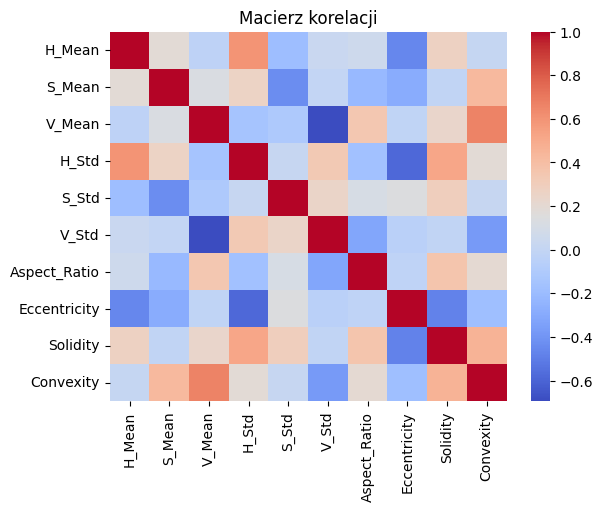

In [585]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation = X_test.corr()
plt.figure()
sns.heatmap(correlation, cmap="coolwarm", annot=False)
plt.title("Macierz korelacji")
plt.show()

Dokładność dtc: 0.8621


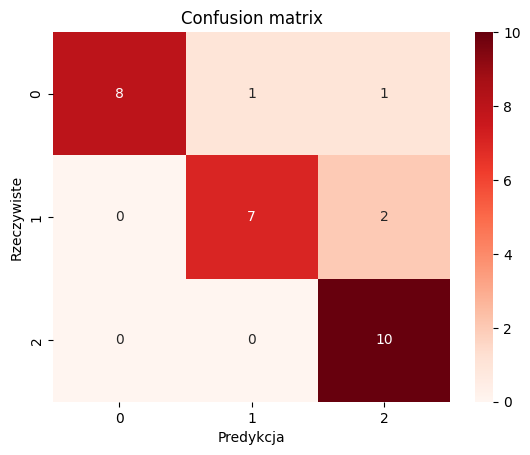

In [586]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print(f'Dokładność dtc: {dtc.score(X_test,y_test):.4}')

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds')
plt.title("Confusion matrix")
plt.xlabel("Predykcja")
plt.ylabel("Rzeczywiste")
plt.show()

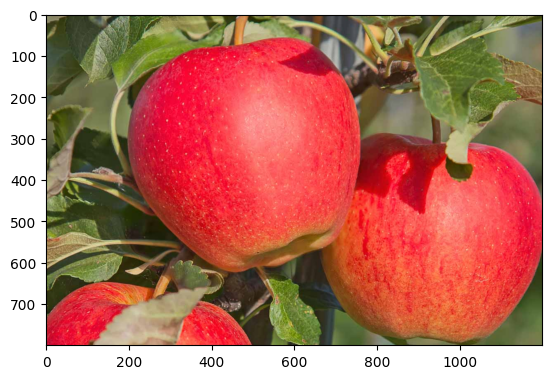

In [587]:
import matplotlib.pyplot as plt
import cv2

test_apple_path = './Image_2.png'
img = cv2.imread(test_apple_path)
if img is None:
    print("Failed to load image:", img)

# matplotlib potrzebuje RGB, cv2 podaje BGR
plt.imshow(BGR2RGB(img))

In [588]:
df_test = pd.DataFrame(columns=column_labels)
extract_features(df_test, test_apple_path, '')
testing_x = df_test.drop('Class', axis=1)
testing_x

,H_Mean,S_Mean,V_Mean,H_Std,S_Std,V_Std,Aspect_Ratio,Eccentricity,Solidity,Convexity
0,56.72323320539149,157.34491454898125,173.0009418966825,67.40502805073015,52.7708519834988,69.34537702356687,1.5,0.7496122936013345,0.987590625,0.8211538883438662


In [589]:
dtc.predict(testing_x)

array(['apple'], dtype=object)

## Feature Visualization

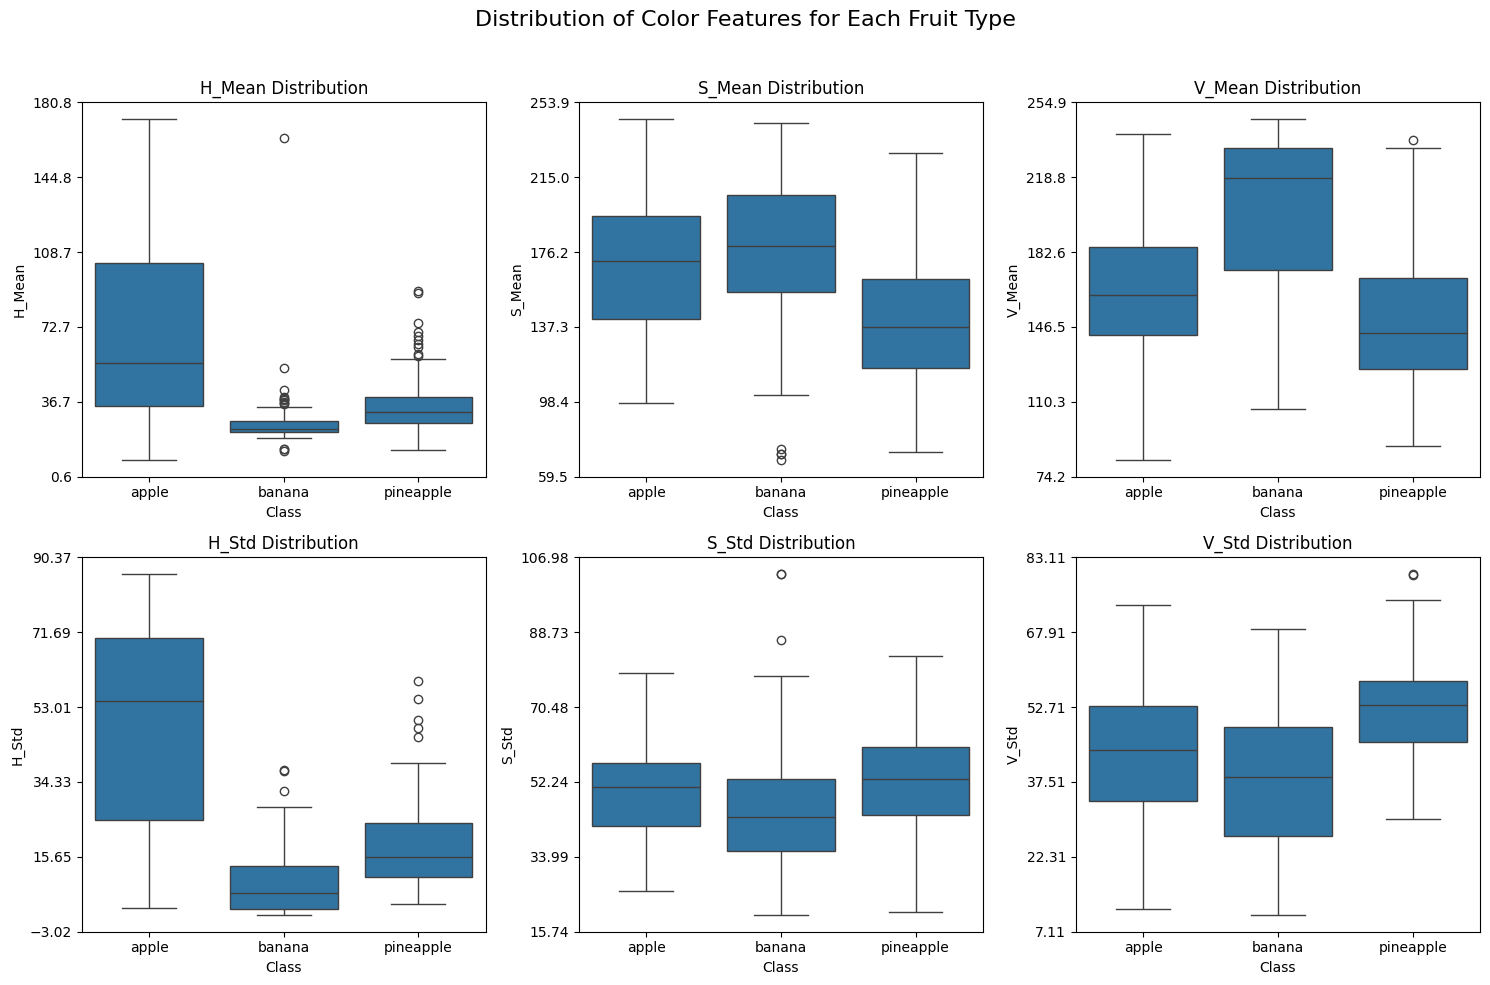

In [594]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as ticker
import numpy as np

# 1. CLEAN THE DATA
# Ensure all color features are numeric. 
# This fixes the "too many ticks" issue if the data was read as strings.
color_features = ['H_Mean', 'S_Mean', 'V_Mean', 'H_Std', 'S_Std', 'V_Std']

# for feature in color_features:
    # errors='coerce' turns non-numeric values into NaN
    # df_train[feature] = pd.to_numeric(df_train[feature], errors='coerce')

# 2. PLOT
plt.figure(figsize=(15, 10))
plt.suptitle('Distribution of Color Features for Each Fruit Type', fontsize=16)

for i, feature in enumerate(color_features, 1):
    ax = plt.subplot(2, 3, i)
    
    sns.boxplot(x='Class', y=feature, data=df_train)
    plt.title(f'{feature} Distribution')
    
    # Force sorted y-ticks
    ymin, ymax = ax.get_ylim()
    num_ticks = 6
    ticks = np.linspace(ymin, ymax, num_ticks)
    ax.set_yticks(ticks)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

<Figure size 1500x500 with 0 Axes>

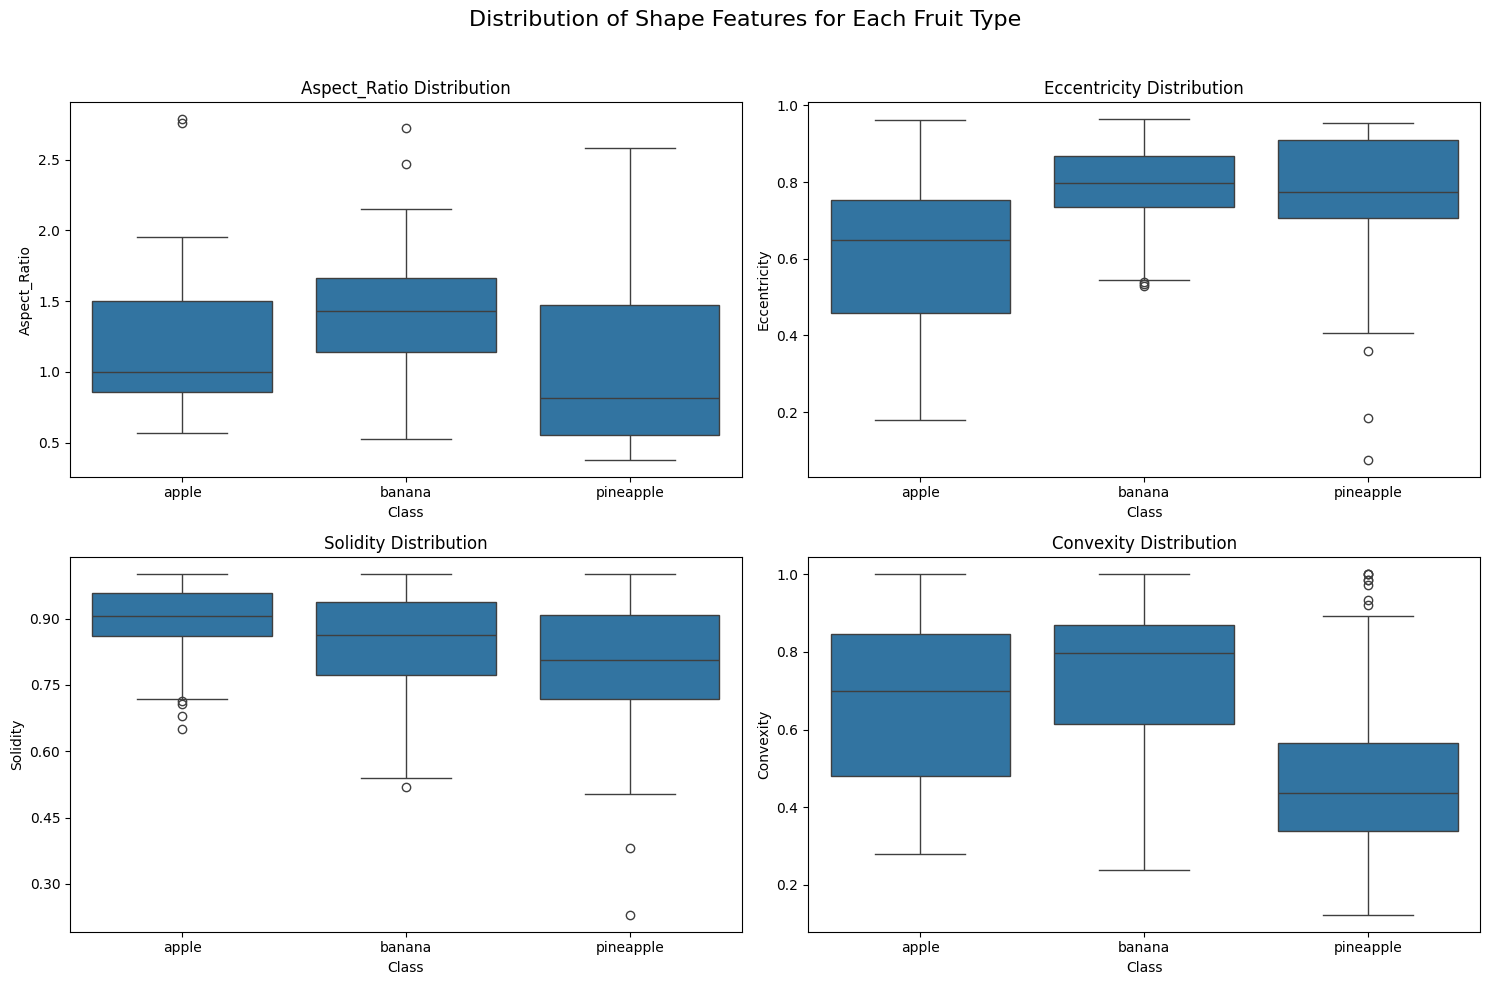

In [595]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.suptitle('Distribution of Shape Features for Each Fruit Type', fontsize=16)

shape_features = ['Aspect_Ratio', 'Eccentricity', 'Solidity', 'Convexity']

plt.figure(figsize=(15, 10))
plt.suptitle('Distribution of Shape Features for Each Fruit Type', fontsize=16)

for i, feature in enumerate(shape_features, 1):
    ax = plt.subplot(2, 2, i)
    
    sns.boxplot(x='Class', y=feature, data=df_train)
    plt.title(f'{feature} Distribution')
    
    # Optional: Explicitly limit Y-axis ticks if they are still too dense
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=6))

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [593]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

# List of classifiers to try
classifiers = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(random_state=42),
    'KNN': KNeighborsClassifier(),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(random_state=42)}

# Train and evaluate each classifier
results = {}
for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    accuracy = clf.score(X_test, y_test)
    results[name] = accuracy
    print(f'{name} Accuracy: {accuracy:.4f}')

# Find the best classifier
best_classifier = max(results, key=results.get)
print(f'\nBest classifier: {best_classifier} with accuracy {results[best_classifier]:.4f}')

Random Forest Accuracy: 0.8966
SVM Accuracy: 0.8966
KNN Accuracy: 0.8276
Logistic Regression Accuracy: 0.8276
Naive Bayes Accuracy: 0.8621
Decision Tree Accuracy: 0.8621

Best classifier: Random Forest with accuracy 0.8966


d:\Magisterka\Semestr 3\Analiza danych multimedialnych\fruit-image-recognition\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [598]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_train, y_train)

y_pred_rf = rfc.predict(X_test)

from sklearn.metrics import accuracy_score
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f'Random Forest Accuracy: {accuracy_rf:.4f}')

Random Forest Accuracy: 0.8966


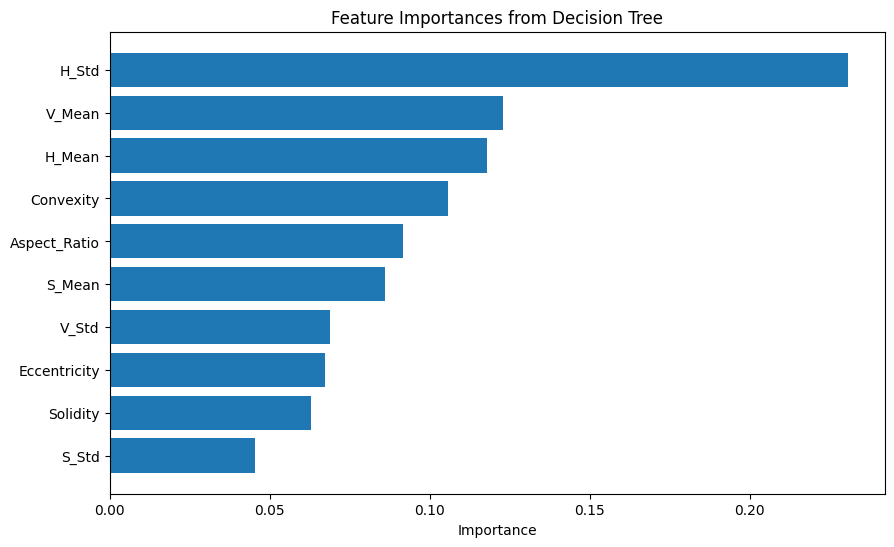

Top features by importance:
H_Std: 0.2307
V_Mean: 0.1228
H_Mean: 0.1181
Convexity: 0.1058
Aspect_Ratio: 0.0918
S_Mean: 0.0862
V_Std: 0.0689
Eccentricity: 0.0674
Solidity: 0.0630
S_Std: 0.0453


In [599]:
import matplotlib.pyplot as plt

# Get feature importances from the decision tree
feature_importances = rfc.feature_importances_
features = X_train.columns

# Sort features by importance
sorted_idx = feature_importances.argsort()

# Plot horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(features[sorted_idx], feature_importances[sorted_idx])
plt.xlabel('Importance')
plt.title('Feature Importances from Decision Tree')
plt.show()

# Print top features
print("Top features by importance:")
for idx in sorted_idx[::-1]:
    print(f"{features[idx]}: {feature_importances[idx]:.4f}")